<a href="https://colab.research.google.com/github/DanielSammaritani/Simple_Trading_Strategy/blob/main/Momentum_roc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use("seaborn-v0_8")

tickers = [
    "IXN",
    "IXJ",
    "IXG",
    "IXC",
    "RXI",
    "KXI",
    "EXI",
    "MXI",
    "IXP",
    "JXI",
    "REET"
]

data = yf.download(tickers ,start="2020-01-01")
print(data)

/tmp/ipykernel_2081/1757949831.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers ,start="2020-01-01")
[*********************100%***********************]  11 of 11 completed

Price            Close                                                 \
Ticker             EXI        IXC         IXG         IXJ         IXN   
Date                                                                    
2020-01-02   89.387093  23.921719   58.735302   63.062153   34.173935   
2020-01-03   88.781181  23.952507   58.161194   62.595844   33.763859   
2020-01-06   88.772141  24.275774   58.034550   62.888428   33.864384   
2020-01-07   88.690742  24.152622   57.781281   62.742149   33.864384   
2020-01-08   89.043449  23.860144   58.000786   63.117008   34.225006   
...                ...        ...         ...         ...         ...   
2026-09-04  197.380005  58.410000  136.199997  104.900002  142.919998   
2026-09-08  197.020004  59.270000  134.559998  101.910004  143.339996   
2026-09-09  194.600006  59.880001  133.279999  101.400002  143.050003   
2026-09-10  192.399994  59.610001  132.899994  100.889999  140.860001   
2026-09-11  195.130005  59.669998  134.229996  100.

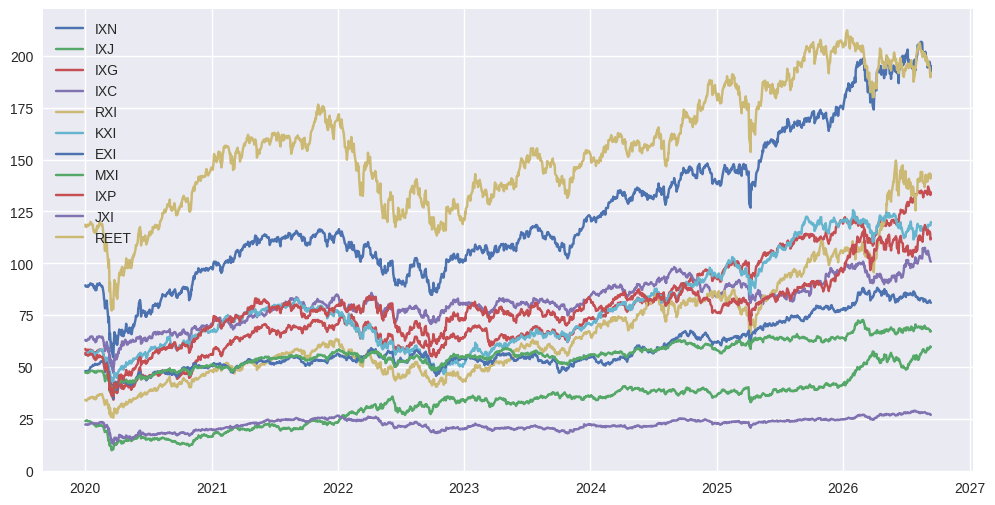

In [40]:

plt.figure(figsize=(12,6))
plt.plot(data["Close"])
plt.legend(tickers)
data.dropna(inplace=True)
plt.show()

In [41]:
Price = data["Close"]
def cum_returns(x):
    ret = np.exp(x.sum())-1
    return ret
def Sharpe(x):
    annualized_growth = np.exp(x.mean()*252)-1
    risk_free_rate_ann = np.exp(0.048)-1
    annualized_volatility = np.sqrt(252)*x.std()
    Sharpe_ratio = (annualized_growth-risk_free_rate_ann)/annualized_volatility
    return Sharpe_ratio
def max_drawdown(x):
    cum_log_ret = x.cumsum()
    equity_line = np.exp(cum_log_ret)
    d_max = equity_line.cummax()
    d = (d_max-equity_line)/d_max
    return d.max()



In [42]:
#strategy
Price14 = data["Close"].shift(14)
ROC = ((Price-Price14)/Price14)*100

signal = pd.DataFrame(np.select([ROC>0,ROC<0], [+1,-1]), index = Price.index, columns = Price.columns)
print(signal)

Ticker      EXI  IXC  IXG  IXJ  IXN  IXP  JXI  KXI  MXI  REET  RXI
Date                                                              
2020-01-02    0    0    0    0    0    0    0    0    0     0    0
2020-01-03    0    0    0    0    0    0    0    0    0     0    0
2020-01-06    0    0    0    0    0    0    0    0    0     0    0
2020-01-07    0    0    0    0    0    0    0    0    0     0    0
2020-01-08    0    0    0    0    0    0    0    0    0     0    0
...         ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...
2026-09-04   -1    1    1    1   -1    1   -1    1    1    -1   -1
2026-09-08   -1    1    1   -1    1    1   -1   -1    1    -1   -1
2026-09-09   -1    1    1   -1    1    1   -1   -1    1    -1   -1
2026-09-10   -1    1    1   -1    1    1   -1   -1   -1    -1   -1
2026-09-11   -1    1    1   -1    1    1   -1   -1   -1    -1   -1

[1682 rows x 11 columns]


In [43]:
log_ret = np.log(Price/Price.shift(1))
strat = log_ret*signal.shift(1)
cum_log_ret = strat.cumsum()
equity_line = np.exp(cum_log_ret)
print(strat)

Ticker           EXI       IXC       IXG       IXJ       IXN       IXP  \
Date                                                                     
2020-01-02       NaN       NaN       NaN       NaN       NaN       NaN   
2020-01-03 -0.000000  0.000000 -0.000000 -0.000000 -0.000000 -0.000000   
2020-01-06 -0.000000  0.000000 -0.000000  0.000000  0.000000  0.000000   
2020-01-07 -0.000000 -0.000000 -0.000000 -0.000000  0.000000 -0.000000   
2020-01-08  0.000000 -0.000000  0.000000  0.000000  0.000000  0.000000   
...              ...       ...       ...       ...       ...       ...   
2026-09-04 -0.001115 -0.008524 -0.005857 -0.010903 -0.012037 -0.002701   
2026-09-08  0.001826  0.014616 -0.012114 -0.028917 -0.002934  0.000929   
2026-09-09  0.012359  0.010239 -0.009558  0.005017 -0.002025 -0.001606   
2026-09-10  0.011370 -0.004519 -0.002855  0.005042 -0.015428  0.001606   
2026-09-11 -0.014090  0.001006  0.009958  0.001289  0.013258  0.012421   

Ticker           JXI       KXI       

In [44]:
metrics = {
    "Cummulative_returns" : cum_returns(strat),
    "Sharpe" : Sharpe(strat),
    "Max_drawdowns" : max_drawdown(strat)

}
show = pd.DataFrame(metrics)
print(show)

        Cummulative_returns    Sharpe  Max_drawdowns
Ticker                                              
EXI                0.362633 -0.008199       0.272217
IXC                0.037582 -0.141309       0.677438
IXG                0.845968  0.210076       0.231399
IXJ                0.175308 -0.142970       0.292481
IXN                0.659874  0.106566       0.349370
IXP                0.203129 -0.100978       0.426995
JXI                0.883124  0.261112       0.255843
KXI                0.411999  0.025426       0.294854
MXI                0.904269  0.228438       0.330521
REET               0.553065  0.087303       0.342514
RXI                0.803525  0.188850       0.360798


In [45]:
metrics1 = {
    "Cummulative_returns" : cum_returns(log_ret),
    "Sharpe" : Sharpe(log_ret),
    "Max_drawdowns" : max_drawdown(log_ret)
}
show1 = pd.DataFrame(metrics1)
print(show1)

        Cummulative_returns    Sharpe  Max_drawdowns
Ticker                                              
EXI                1.182977  0.363024       0.395600
IXC                1.494386  0.316120       0.595434
IXG                1.285338  0.368928       0.414849
IXJ                0.597789  0.136744       0.273522
IXN                3.176868  0.679973       0.363026
IXP                1.140321  0.343550       0.439273
JXI                0.683793  0.165468       0.342019
KXI                0.423260  0.033561       0.245878
MXI                0.970715  0.253057       0.365462
REET               0.216549 -0.088539       0.445909
RXI                0.618216  0.111915       0.357798


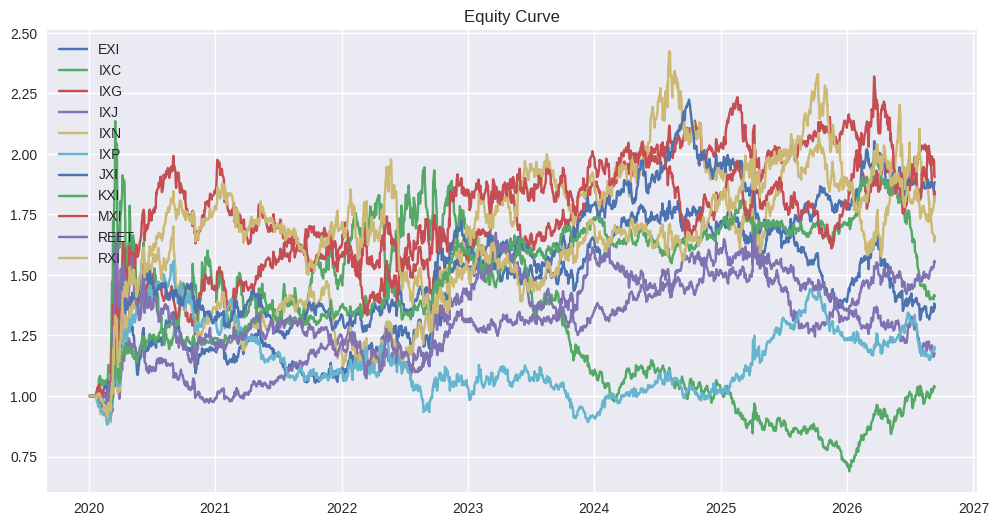

In [46]:
plt.figure(figsize=(12,6))
plt.plot(equity_line)
plt.title("Equity Curve")
plt.legend(show.index)
plt.show()